# Gemma 4 H/k v2_planact Sweep Notebook

Dieses Notebook startet den H/k-Agent-Runner fuer den 12-Task-Sweep mit `gemma4:26b` als Planner und `gemma4:e4b` als Executor. Standardmaessig laeuft es ueber den lokalen Ollama-kompatiblen Proxy zur Google Vertex AI MaaS API.

Methodischer Hinweis fuer die Masterarbeit: `v2_planact` ist eine Architekturvariante zur besseren Executor-Grounding-/Replanning-Kontrolle. Die WebArena-Verified Task-Prompts, Task-Contracts und finale offizielle Evaluation bleiben die Grundlage. Die zusaetzlichen PlanAct-Regeln duerfen keine Gold-Antworten, keine Evaluator-Metadaten und keine task-spezifisch hardcodierten Loesungen einfuehren.

Der Runner darf weiterhin `gemma4:26b` und `gemma4:e4b` als Modellnamen loggen; der Proxy routet beide Namen intern auf `VERTEX_MAAS_MODEL`, z.B. `gemma-4-26b-a4b-it-maas`. Wenn du stattdessen lokal mit Ollama laufen willst, setze `USE_VERTEX_PROXY = False`.


In [175]:
from pathlib import Path
import json
import math
import os
import shutil
import subprocess
import sys
import time
from urllib.request import Request, urlopen

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

# Main sweep requested for the thesis run.
EXPERIMENT_NAME = 'hk-agent-browsergym-planact-main-v01'
TASK_IDS = [44, 157, 105, 522, 800, 444, 407, 644, 28, 387, 795, 507, 505, 15, 108]
#TASK_IDS = [44, 157, 105, 522, 800, 444, 407, 644, 28, 387]  # smaller sweep for debugging
HS = [0, 2, 5, 10]
KS = [0, 2, 5, 10]
RUN_MODE = 'agent'
# Wenn True, druckt die Run-Zelle nur den fertigen Terminal-Befehl und startet keinen Sweep.
PRINT_COMMAND_ONLY = True
# Wenn True, bewahrt der Runner alte summary-Zeilen und ueberspringt vorhandene Run-Artefakte.
RESUME_SUMMARY = True
# Sauber, aber langsam: startet bei offiziellen MUTATE-Tasks den jeweiligen WebArena-Service neu.
RESET_SITE_BEFORE_MUTATE = False
SITE_RESET_TIMEOUT_SECONDS = 180
# Schnelle Zusatzmetrik: eindeutige Duplicate-Suffixe wie x-lab14 zaehlen nur als transparente Diagnose, nicht als official_success.
USE_CONTAMINATION_ADJUSTED_SUCCESS = True
SUCCESS_POLICY = 'contamination_adjusted' if USE_CONTAMINATION_ADJUSTED_SUCCESS else 'webarena'
# Aktualisiert alte summary-Zeilen aus vorhandenen Artefakten, ohne Aufgaben neu zu starten.
REFRESH_EXISTING_DIAGNOSTICS = True
# Wenn True, werden nur vorhandene Artefakte neu bewertet; fehlende H/K-Kombinationen werden nicht gestartet.
REFRESH_EXISTING_ONLY = False
PLANNER_MODEL = 'gemma4:26b'
EXECUTOR_MODEL = 'gemma4:e4b'
AGENT_ARCHITECTURE = 'v2_planact'
MAX_STEPS_POLICY = 'tiered'
MAX_STEPS = 40  # fallback/fixed-budget value; tiered runs use the per-tier values below.
MAX_STEPS_BY_CAPABILITY_TIER = {
    'navigation': 15,
    'visible_retrieve': 25,
    'structured_retrieve': 25,
    'policy': 15,
    'mutation': 45,
}
PLANNER_CALL_MARGIN = 2
MAX_PLANNER_CALLS = 'auto'

def planner_call_budget_for_h(h, max_steps, margin=PLANNER_CALL_MARGIN):
    if max_steps <= 0:
        return None
    if h <= 0:
        return max(3, margin + 1)
    return math.ceil(max_steps / h) + margin

PLANNER_CALL_BUDGET_BY_TIER_AND_H = {
    tier: {h: planner_call_budget_for_h(h, max_steps) for h in HS}
    for tier, max_steps in MAX_STEPS_BY_CAPABILITY_TIER.items()
}
EXPECTED_RUNS = len(TASK_IDS) * len(HS) * len(KS)
LLM_TIMEOUT_SECONDS = 600
# 0 keeps full H/k execution comparable to older runs. Use 2 for quick smoke/debug runs.
MAX_CONSECUTIVE_LLM_TIMEOUTS = 0

# Prompt provenance: WebArena-Verified prompt basis + local architecture extension.
PLANNER_PROMPT_PATH = ROOT / 'prompts/planner_system.md'
PLANNER_USER_TEMPLATE_PATH = ROOT / 'prompts/prompt_user_template.md'
EXECUTOR_PROMPT_PATH = ROOT / 'prompts/executor_system.md'
WEBARENA_VERIFIED_PROMPT_ROOT = ROOT / 'external/webarena-verified/examples/prompts'
ARCHITECTURE_EXTENSION_PROMPT_ROOT = ROOT / 'prompts/v2'

# Default: run the same sweep through Google Vertex AI MaaS via the local proxy.
USE_VERTEX_PROXY = True
LOCAL_OLLAMA_URL = 'http://localhost:11434'
PROXY_URL = 'http://127.0.0.1:11435'

# Optional Vertex MaaS proxy settings, only used when USE_VERTEX_PROXY=True.
PROJECT_ID = os.environ.get('GOOGLE_CLOUD_PROJECT', 'project-e784413d-cd26-4398-adf')
LOCATION = os.environ.get('GOOGLE_CLOUD_LOCATION', 'global')
VERTEX_MAAS_MODEL = os.environ.get('VERTEX_MAAS_MODEL', 'gemma-4-26b-a4b-it-maas')
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
os.environ['GOOGLE_CLOUD_LOCATION'] = LOCATION
os.environ['VERTEX_MAAS_MODEL'] = VERTEX_MAAS_MODEL
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'True'

ROOT, EXPERIMENT_NAME, AGENT_ARCHITECTURE, TASK_IDS, HS, KS, MAX_STEPS_POLICY, MAX_STEPS_BY_CAPABILITY_TIER, MAX_PLANNER_CALLS, PLANNER_CALL_BUDGET_BY_TIER_AND_H, EXPECTED_RUNS, PLANNER_MODEL, EXECUTOR_MODEL, USE_VERTEX_PROXY, PRINT_COMMAND_ONLY, RESUME_SUMMARY


(PosixPath('/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code'),
 'hk-agent-browsergym-planact-main-v02_basis_v3',
 'v2_planact',
 [44, 157, 105, 522, 800, 444, 407, 644, 28, 387, 795, 507, 505, 15, 108],
 [0, 2, 5, 10],
 [0, 2, 5, 10],
 'tiered',
 {'navigation': 15,
  'visible_retrieve': 25,
  'structured_retrieve': 25,
  'policy': 15,
  'mutation': 45},
 'auto',
 {'navigation': {0: 3, 2: 10, 5: 5, 10: 4},
  'visible_retrieve': {0: 3, 2: 15, 5: 7, 10: 5},
  'structured_retrieve': {0: 3, 2: 15, 5: 7, 10: 5},
  'policy': {0: 3, 2: 10, 5: 5, 10: 4},
  'mutation': {0: 3, 2: 25, 5: 11, 10: 7}},
 240,
 'gemma4:26b',
 'gemma4:e4b',
 True,
 True,
 True)

## 0. WebArena-Docker-Services automatisch neu starten

Diese Zelle startet die WebArena-Services fuer die aktuelle Experimentliste neu. Das ist besonders vor MUTATE-Retests hilfreich, weil GitLab/Shopping/Reddit sonst bereits veraenderte Daten enthalten koennen. Wenn du nur den Befehl sehen willst, setze `AUTO_RESTART_WEBARENA_CONTAINERS = False`.


In [178]:
# Achtung: `env start` entfernt den bestehenden Container des jeweiligen Sites und startet ihn frisch.
# Wenn diese Zelle laeuft, werden die Services automatisch neu gestartet.
AUTO_RESTART_WEBARENA_CONTAINERS = True
RESTART_WITH_DIRECT_DOCKER_RUN = True  # True = docker rm/run statt webarena-verified env start.
RESTART_NEEDED_SITES_EVEN_IF_STOPPED = True  # True = fuer TASK_IDS benoetigte Sites ebenfalls starten.
AUTO_CLEAR_WEBARENA_PORT_CONFLICTS = True  # Stoppt Docker-Container, die WebArena-Ports blockieren.
DOCKER_PLATFORM = 'linux/amd64'  # Apple Silicon: verhindert Platform-Warnungen bei WebArena-Images.
WEBARENA_SITES_TO_CHECK = ['shopping', 'shopping_admin', 'reddit', 'gitlab']
WEBARENA_SITE_HOST_PORTS = {
    'shopping': [7770, 7771],
    'shopping_admin': [7780, 7781],
    'reddit': [9999, 9998],
    'gitlab': [8023, 8024],
}
WEBARENA_DOCKER_CONFIG = {
    'shopping': {
        'name': 'webarena-verified-shopping',
        'cli_name': 'webarena_verified_shopping',
        'ports': ['7770:80', '7771:8877'],
        'image': 'am1n3e/webarena-verified-shopping',
    },
    'shopping_admin': {
        'name': 'webarena-verified-shopping_admin',
        'cli_name': 'webarena_verified_shopping_admin',
        'ports': ['7780:80', '7781:8877'],
        'image': 'am1n3e/webarena-verified-shopping_admin',
    },
    'reddit': {
        'name': 'webarena-verified-reddit',
        'cli_name': 'webarena_verified_reddit',
        'ports': ['9999:80', '9998:8877'],
        'image': 'am1n3e/webarena-verified-reddit',
    },
    'gitlab': {
        'name': 'webarena-verified-gitlab',
        'cli_name': 'webarena_verified_gitlab',
        'ports': ['8023:8023', '8024:8877'],
        'image': 'am1n3e/webarena-verified-gitlab',
    },
}

wa_root = ROOT / 'external/webarena-verified'
assert wa_root.exists(), wa_root

def docker_containers_on_ports(ports):
    proc = subprocess.run(
        ['docker', 'ps', '--format', '{{.ID}}\t{{.Names}}\t{{.Ports}}'],
        text=True,
        capture_output=True,
        check=False,
    )
    if proc.returncode != 0:
        print(proc.stderr[-2000:])
        return []
    markers = [f':{port}->' for port in ports]
    conflicts = []
    for line in proc.stdout.splitlines():
        parts = line.split('\t', 2)
        if len(parts) != 3:
            continue
        container_id, name, published_ports = parts
        if any(marker in published_ports for marker in markers):
            conflicts.append({'id': container_id, 'name': name, 'ports': published_ports})
    return conflicts

def clear_port_conflicts_for_site(site):
    conflicts = docker_containers_on_ports(WEBARENA_SITE_HOST_PORTS.get(site, []))
    if not conflicts:
        return []
    print(f'Port conflicts for {site}:', conflicts)
    if not AUTO_CLEAR_WEBARENA_PORT_CONFLICTS:
        return conflicts
    for conflict in conflicts:
        print('Stopping/removing conflicting container:', conflict)
        subprocess.run(['docker', 'stop', conflict['id']], text=True, capture_output=True, check=False)
        subprocess.run(['docker', 'rm', '-f', conflict['id']], text=True, capture_output=True, check=False)
    return conflicts

def remove_known_webarena_containers(site):
    config = WEBARENA_DOCKER_CONFIG[site]
    for name in [config['name'], config['cli_name']]:
        subprocess.run(['docker', 'rm', '-f', name], text=True, capture_output=True, check=False)

def direct_docker_run_command(site):
    config = WEBARENA_DOCKER_CONFIG[site]
    cmd = ['docker', 'run', '-d', '--platform', DOCKER_PLATFORM, '--name', config['name']]
    for port in config['ports']:
        cmd.extend(['-p', port])
    cmd.append(config['image'])
    return cmd

running_sites = []
for site in WEBARENA_SITES_TO_CHECK:
    status_cmd = ['uv', 'run', 'webarena-verified', 'env', 'status', '--site', site]
    status_proc = subprocess.run(status_cmd, cwd=wa_root, text=True, capture_output=True, check=False)
    if status_proc.returncode == 0:
        running_sites.append(site)

sites_needed = []
if RESTART_NEEDED_SITES_EVEN_IF_STOPPED:
    if str(ROOT / 'scripts') not in sys.path:
        sys.path.insert(0, str(ROOT / 'scripts'))
    from hk_agent.task_loader import select_tasks

    selected_tasks = select_tasks(
        ROOT / 'external/webarena-verified',
        TASK_IDS,
        single_site_only=True,
        supported_sites_only=True,
        allow_non_hard_task_ids=False,
    )
    for task in selected_tasks:
        sites_needed.extend(task.sites or [task.primary_site])
sites_to_restart = sorted(set(running_sites) | {site for site in sites_needed if site})
if not sites_to_restart:
    sites_to_restart = WEBARENA_SITES_TO_CHECK

restart_plan = []
for site in sites_to_restart:
    if RESTART_WITH_DIRECT_DOCKER_RUN:
        start_cmd = direct_docker_run_command(site)
    else:
        start_cmd = [
            'uv', 'run', 'webarena-verified', 'env', 'start',
            '--site', site,
            '--timeout', str(SITE_RESET_TIMEOUT_SECONDS),
        ]
    restart_plan.append({'site': site, 'cmd': start_cmd})

print('running_sites:', running_sites)
print('sites_needed_by_TASK_IDS:', sorted({site for site in sites_needed if site}))
print('WebArena restart plan:')
for item in restart_plan:
    print(f"- {item['site']}:", ' '.join(item['cmd']))

if AUTO_RESTART_WEBARENA_CONTAINERS:
    for item in restart_plan:
        print(f"\nRestarting {item['site']} ...")
        if RESTART_WITH_DIRECT_DOCKER_RUN:
            remove_known_webarena_containers(item['site'])
            clear_port_conflicts_for_site(item['site'])
            proc = subprocess.run(item['cmd'], cwd=ROOT, text=True, capture_output=True, check=False)
        else:
            stop_cmd = ['uv', 'run', 'webarena-verified', 'env', 'stop', '--site', item['site']]
            subprocess.run(stop_cmd, cwd=wa_root, text=True, capture_output=True, check=False)
            proc = subprocess.run(item['cmd'], cwd=wa_root, text=True, capture_output=True, check=False)
        print(proc.stdout[-2000:])
        if proc.returncode != 0:
            err = (proc.stderr or proc.stdout or '')
            print(err[-4000:])
            if 'port is already allocated' in err.lower() or 'bind for' in err.lower():
                clear_port_conflicts_for_site(item['site'])
                print(f"Retrying {item['site']} after clearing port conflicts ...")
                proc = subprocess.run(item['cmd'], cwd=ROOT if RESTART_WITH_DIRECT_DOCKER_RUN else wa_root, text=True, capture_output=True, check=False)
                print(proc.stdout[-2000:])
                if proc.returncode != 0:
                    print((proc.stderr or proc.stdout or '')[-4000:])
                    raise RuntimeError(f"Restart retry failed for {item['site']} with return code {proc.returncode}")
            else:
                raise RuntimeError(f"Restart failed for {item['site']} with return code {proc.returncode}")
    print('\nWebArena services restarted:', ', '.join(item['site'] for item in restart_plan))
else:
    print('\nAUTO_RESTART_WEBARENA_CONTAINERS=False; es wurde nichts neu gestartet.')


running_sites: []
sites_needed_by_TASK_IDS: ['gitlab', 'reddit', 'shopping', 'shopping_admin']
WebArena restart plan:
- gitlab: docker run -d --platform linux/amd64 --name webarena-verified-gitlab -p 8023:8023 -p 8024:8877 am1n3e/webarena-verified-gitlab
- reddit: docker run -d --platform linux/amd64 --name webarena-verified-reddit -p 9999:80 -p 9998:8877 am1n3e/webarena-verified-reddit
- shopping: docker run -d --platform linux/amd64 --name webarena-verified-shopping -p 7770:80 -p 7771:8877 am1n3e/webarena-verified-shopping
- shopping_admin: docker run -d --platform linux/amd64 --name webarena-verified-shopping_admin -p 7780:80 -p 7781:8877 am1n3e/webarena-verified-shopping_admin

Restarting gitlab ...
ffd85fefe8c0cc518654be2b830fcd41fdbaef083dd3fa90000f64f4ca732216


Restarting reddit ...
0e903f6db89b4170042c6aeed3372766cd07ede69cbab6b0e97b31fdbf203b84


Restarting shopping ...
b7c49bbfb670abf26b1ed947c9c56eef037ea5ec9a1731826379acb1e3203f48


Restarting shopping_admin ...
99bbe9f75c

## 0b. MUTATE-Retest auf sauberem Zustand

Diese Zelle baut und optional startet kleine MUTATE-Retests. Standard ist `h2/k2`, weil diese Kombination aktuell die sinnvollste PlanAct-Variante testet. Wenn du zusaetzlich Baseline willst, setze `MUTATE_RETEST_HK_PAIRS = [(0, 0), (2, 2)]`.


In [176]:
if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))

from hk_agent.task_loader import select_tasks
from hk_agent.capabilities import infer_official_task_type

RUN_MUTATE_RETEST = False  # True = Retest direkt starten; False = nur Befehle ausgeben.
MUTATE_RETEST_EXPERIMENT_NAME = f'{EXPERIMENT_NAME}-mutate-retest-clean'
MUTATE_RETEST_HK_PAIRS = [(2, 2)]  # z.B. [(0, 0), (2, 2)] fuer Baseline plus PlanAct.
MUTATE_RETEST_RESET_BEFORE_MUTATE = False  # False, wenn die Restart-Zelle direkt davor gelaufen ist.

tasks_for_current_ids = select_tasks(
    ROOT / 'external/webarena-verified',
    TASK_IDS,
    single_site_only=True,
    supported_sites_only=True,
    allow_non_hard_task_ids=False,
)
MUTATE_RETEST_TASK_IDS = [
    int(task.task_id)
    for task in tasks_for_current_ids
    if infer_official_task_type(task.raw_task) == 'MUTATE'
]

print('mutate_retest_task_ids:', MUTATE_RETEST_TASK_IDS)
print('mutate_retest_hk_pairs:', MUTATE_RETEST_HK_PAIRS)

mutate_retest_commands = []
for h, k in MUTATE_RETEST_HK_PAIRS:
    retest_cmd = [
        'uv', 'run', 'python', 'scripts/run_hk_agent_experiment.py',
        '--experiment-name', MUTATE_RETEST_EXPERIMENT_NAME,
        '--task-ids', *[str(task_id) for task_id in MUTATE_RETEST_TASK_IDS],
        '--hs', str(h),
        '--ks', str(k),
        '--run-mode', RUN_MODE,
        '--planner-model', PLANNER_MODEL,
        '--executor-model', EXECUTOR_MODEL,
        '--agent-architecture', AGENT_ARCHITECTURE,
        '--max-steps-policy', MAX_STEPS_POLICY,
        '--max-steps-navigation', str(MAX_STEPS_BY_CAPABILITY_TIER['navigation']),
        '--max-steps-retrieval', str(MAX_STEPS_BY_CAPABILITY_TIER['structured_retrieve']),
        '--max-steps-policy-task', str(MAX_STEPS_BY_CAPABILITY_TIER['policy']),
        '--max-steps-mutation', str(MAX_STEPS_BY_CAPABILITY_TIER['mutation']),
        '--max-planner-calls', str(MAX_PLANNER_CALLS),
        '--planner-call-margin', str(PLANNER_CALL_MARGIN),
        '--max-steps', str(MAX_STEPS),
        '--llm-timeout-seconds', str(LLM_TIMEOUT_SECONDS),
        '--max-consecutive-llm-timeouts', str(MAX_CONSECUTIVE_LLM_TIMEOUTS),
        '--success-policy', SUCCESS_POLICY,
        '--resume-summary',
        '--refresh-existing-diagnostics',
    ]
    if USE_VERTEX_PROXY:
        retest_cmd.extend(['--ollama-base-url', PROXY_URL])
    else:
        retest_cmd.extend(['--ollama-base-url', LOCAL_OLLAMA_URL])
    if MUTATE_RETEST_RESET_BEFORE_MUTATE:
        retest_cmd.extend(['--reset-site-before-mutate', '--site-reset-timeout-seconds', str(SITE_RESET_TIMEOUT_SECONDS)])
    mutate_retest_commands.append(retest_cmd)

for retest_cmd in mutate_retest_commands:
    print('\n' + ' '.join(retest_cmd))

if RUN_MUTATE_RETEST:
    for retest_cmd in mutate_retest_commands:
        print('\nRunning:', ' '.join(retest_cmd))
        proc = subprocess.run(retest_cmd, cwd=ROOT, env=runner_env if 'runner_env' in globals() else None, text=True, check=False)
        if proc.returncode != 0:
            raise RuntimeError(f'MUTATE retest failed with return code {proc.returncode}')
    print('\nMUTATE retest summary:', ROOT / 'runs/hk-agent' / MUTATE_RETEST_EXPERIMENT_NAME / 'summary.csv')
else:
    print('\nRUN_MUTATE_RETEST=False; Befehle wurden nur gedruckt.')


mutate_retest_task_ids: [522, 800, 444, 407, 644, 795, 507, 505]
mutate_retest_hk_pairs: [(2, 2)]

uv run python scripts/run_hk_agent_experiment.py --experiment-name hk-agent-browsergym-planact-main-v02_basis_v3-mutate-retest-clean --task-ids 522 800 444 407 644 795 507 505 --hs 2 --ks 2 --run-mode agent --planner-model gemma4:26b --executor-model gemma4:e4b --agent-architecture v2_planact --max-steps-policy tiered --max-steps-navigation 15 --max-steps-retrieval 25 --max-steps-policy-task 15 --max-steps-mutation 45 --max-planner-calls auto --planner-call-margin 2 --max-steps 40 --llm-timeout-seconds 600 --max-consecutive-llm-timeouts 0 --success-policy contamination_adjusted --resume-summary --refresh-existing-diagnostics --ollama-base-url http://127.0.0.1:11435

RUN_MUTATE_RETEST=False; Befehle wurden nur gedruckt.


## 1. Prompt Provenance And Thesis Guardrails

Diese Zelle dokumentiert vor dem Lauf, welche Prompt-Dateien verwendet werden. Wichtig fuer die Nachvollziehbarkeit: Die Basis-Prompts kommen aus `external/webarena-verified/examples/prompts/`. `prompts/v2/` ergaenzt nur Architekturregeln fuer Grounding, Validierung, MUTATE-Sorgfalt und Artefakt-Logging.


In [177]:
import hashlib

assert AGENT_ARCHITECTURE == 'v2_planact', AGENT_ARCHITECTURE
assert WEBARENA_VERIFIED_PROMPT_ROOT.exists(), WEBARENA_VERIFIED_PROMPT_ROOT
assert ARCHITECTURE_EXTENSION_PROMPT_ROOT.exists(), ARCHITECTURE_EXTENSION_PROMPT_ROOT

def sha256_short(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()[:16]

site_prompt_files = sorted({WEBARENA_VERIFIED_PROMPT_ROOT / f'{site}.md' for site in ['gitlab', 'reddit', 'shopping', 'shopping_admin']})
prompt_files = [
    PLANNER_PROMPT_PATH,
    PLANNER_USER_TEMPLATE_PATH,
    EXECUTOR_PROMPT_PATH,
    ARCHITECTURE_EXTENSION_PROMPT_ROOT / 'executor_base.md',
    *site_prompt_files,
]
records = []
for prompt_file in prompt_files:
    records.append({
        'path': str(prompt_file.relative_to(ROOT)),
        'exists': prompt_file.exists(),
        'sha256_16': sha256_short(prompt_file) if prompt_file.exists() else None,
        'role': 'webarena_verified_basis' if WEBARENA_VERIFIED_PROMPT_ROOT in prompt_file.parents else 'local_architecture_or_runner_prompt',
    })

print(json.dumps({
    'architecture': AGENT_ARCHITECTURE,
    'official_evaluator': 'WebArena-Verified eval-tasks',
    'prompt_policy': 'WebArena-Verified example prompts are rendered as the executor prompt basis; v2_planact appends grounding and validation rules only.',
    'no_gold_metadata_policy': 'Do not expose official eval answers or evaluator internals to the agent.',
    'prompt_files': records,
}, indent=2))

missing = [record['path'] for record in records if not record['exists']]
if missing:
    raise FileNotFoundError(missing)


AssertionError: v2_planact

## 2. Optional Vertex Authentication Check

Diese Zelle ist nur notwendig, wenn `USE_VERTEX_PROXY = True` gesetzt ist. Fuer den Standardlauf mit lokalem Ollama kannst du sie ueberspringen.


In [154]:
if not USE_VERTEX_PROXY:
    print('USE_VERTEX_PROXY=False; ADC check skipped. Local Ollama will be used.')
else:
    import google.auth
    import google.auth.transport.requests
    from google.auth.exceptions import DefaultCredentialsError

    RUN_ADC_SETUP = False  # auf True setzen, wenn du den Google-ADC-Login aus dem Notebook starten willst
    RUN_GCLOUD_ADC_LOGIN = False  # Alternative, falls gcloud installiert ist
    ENABLE_VERTEX_AI_API = False  # optional: setzt gcloud voraus und braucht passende Rechte im Projekt

    print('PROJECT_ID:', PROJECT_ID)
    print('LOCATION:', LOCATION)
    print('VERTEX_MAAS_MODEL:', VERTEX_MAAS_MODEL)
    print('Login-E-Mail im Browser waehlen:', 'niclascramer@gmail.com')

    if RUN_ADC_SETUP:
        # Startet den offiziellen Google ADC Setup Flow. Das kann einen Browser/Login-Link oeffnen.
        subprocess.run(
            ['bash', '-lc', 'bash <(curl -sSL https://storage.googleapis.com/cloud-samples-data/adc/setup_adc.sh)'],
            check=True,
        )

    if RUN_GCLOUD_ADC_LOGIN:
        if not shutil.which('gcloud'):
            raise RuntimeError('gcloud ist nicht installiert. Nutze RUN_ADC_SETUP=True oder fuehre den curl-Befehl im Terminal aus.')
        subprocess.run(['gcloud', 'auth', 'application-default', 'login'], check=True)
        subprocess.run(['gcloud', 'config', 'set', 'project', PROJECT_ID], check=True)

    if ENABLE_VERTEX_AI_API:
        if not shutil.which('gcloud'):
            raise RuntimeError('gcloud ist nicht installiert; Vertex AI API bitte in der Cloud Console aktivieren.')
        subprocess.run(['gcloud', 'services', 'enable', 'aiplatform.googleapis.com', '--project', PROJECT_ID], check=True)

    try:
        credentials, detected_project = google.auth.default(scopes=['https://www.googleapis.com/auth/cloud-platform'])
        credentials.refresh(google.auth.transport.requests.Request())
        print('ADC OK')
        print('configured_project:', PROJECT_ID)
        print('detected_project:', detected_project)
        print('token_prefix:', str(credentials.token)[:12] + '...')
    except DefaultCredentialsError as exc:
        print('ADC fehlt noch.')
        print('Empfohlen: Im Terminal ausfuehren, Login mit niclascramer@gmail.com waehlen, danach Kernel neu starten:')
        print('bash <(curl -sSL https://storage.googleapis.com/cloud-samples-data/adc/setup_adc.sh)')
        print('Oder in dieser Zelle RUN_ADC_SETUP = True setzen und erneut ausfuehren.')
        raise


PROJECT_ID: project-e784413d-cd26-4398-adf
LOCATION: global
VERTEX_MAAS_MODEL: gemma-4-26b-a4b-it-maas
Login-E-Mail im Browser waehlen: niclascramer@gmail.com
ADC OK
configured_project: project-e784413d-cd26-4398-adf
detected_project: project-e784413d-cd26-4398-adf
token_prefix: ya29.a0AQvPy...


## 3. Optional Vertex-Ollama Proxy

Nur ausfuehren, wenn `USE_VERTEX_PROXY=True`. Der Proxy nimmt Ollama-kompatible `/api/chat` Requests vom Runner entgegen und schickt sie zur Google Vertex AI MaaS API. Mit `--force-default-model` werden lokale Namen wie `gemma4:26b` intern auf `VERTEX_MAAS_MODEL` gemappt.


In [155]:
proxy_proc = None
proxy_reused_existing = False

def proxy_is_ready(url: str, timeout: int = 3) -> bool:
    try:
        req = Request(url.rstrip('/') + '/api/tags', method='GET')
        with urlopen(req, timeout=timeout) as response:
            payload = json.loads(response.read().decode('utf-8'))
        print('proxy_ready:', url, payload)
        return True
    except Exception as exc:
        print('proxy_not_ready:', url, exc)
        return False

if not USE_VERTEX_PROXY:
    print('USE_VERTEX_PROXY=False; proxy not started.')
elif proxy_is_ready(PROXY_URL):
    proxy_reused_existing = True
    print('proxy_reused_existing:', PROXY_URL)
else:
    proxy_cmd = [
        sys.executable,
        str(ROOT / 'scripts/vertex_ollama_proxy.py'),
        '--host', '127.0.0.1',
        '--port', '11435',
        '--project-id', PROJECT_ID,
        '--location', LOCATION,
        '--model', VERTEX_MAAS_MODEL,
        '--force-default-model',
    ]

    proxy_env = os.environ.copy()
    proxy_env['PYTHONPATH'] = str(ROOT / 'scripts') + os.pathsep + proxy_env.get('PYTHONPATH', '')

    proxy_proc = subprocess.Popen(
        proxy_cmd,
        cwd=ROOT,
        env=proxy_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )

    time.sleep(3)
    print('proxy_pid:', proxy_proc.pid)
    if proxy_proc.poll() is not None:
        output = proxy_proc.stdout.read() if proxy_proc.stdout else ''
        print(output)
        if 'Address already in use' in output and proxy_is_ready(PROXY_URL):
            proxy_proc = None
            proxy_reused_existing = True
            print('proxy_reused_existing_after_port_conflict:', PROXY_URL)
        else:
            raise RuntimeError('Proxy exited early')
    elif proxy_is_ready(PROXY_URL):
        print('proxy_started')
    else:
        raise RuntimeError('Proxy process started but /api/tags is not reachable')


proxy_not_ready: http://127.0.0.1:11435 timed out
proxy_pid: 29346
Traceback (most recent call last):
  File "/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/scripts/vertex_ollama_proxy.py", line 235, in <module>
    raise SystemExit(main())
                     ^^^^^^
  File "/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/scripts/vertex_ollama_proxy.py", line 224, in main
    server = ThreadingHTTPServer((args.host, args.port), make_handler(client))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/socketserver.py", line 457, in __init__
    self.server_bind()
  File "/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/http/server.py", line 140, in server_bind
    socketserver.TCPServer.server_bind(self)
  File "/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks

RuntimeError: Proxy exited early

## 4. Optional JSON Smoke Test

Prueft entweder den Vertex-Proxy oder lokales Ollama mit einem kleinen JSON-Call.


In [126]:
smoke_url = PROXY_URL if USE_VERTEX_PROXY else LOCAL_OLLAMA_URL
smoke_model = VERTEX_MAAS_MODEL if USE_VERTEX_PROXY else PLANNER_MODEL
payload = {
    'model': smoke_model,
    'stream': False,
    'format': 'json',
    'messages': [
        {'role': 'system', 'content': 'Return valid JSON only.'},
        {'role': 'user', 'content': 'Return {"ok": true, "model": "gemma"} as JSON.'},
    ],
    'options': {'temperature': 0.0, 'top_p': 0.95, 'num_predict': 128},
}
req = Request(
    smoke_url + '/api/chat',
    data=json.dumps(payload).encode('utf-8'),
    headers={'Content-Type': 'application/json'},
    method='POST',
)
started = time.perf_counter()
with urlopen(req, timeout=600) as resp:
    raw = resp.read().decode('utf-8')
elapsed = time.perf_counter() - started
decoded = json.loads(raw)
print('endpoint:', smoke_url)
print('model:', smoke_model)
print('elapsed_seconds:', round(elapsed, 3))
print('prompt_tokens:', decoded.get('prompt_eval_count'))
print('completion_tokens:', decoded.get('eval_count'))
print('content:', decoded.get('message', {}).get('content'))


endpoint: http://127.0.0.1:11435
model: gemma-4-26b-a4b-it-maas
elapsed_seconds: 0.467
prompt_tokens: 39
completion_tokens: 20
content: {
  "ok": true,
  "model": "gemma"
}


## 5. Run The H/k Sweep

Diese Zelle startet den angefragten Sweep mit `v2_planact`. Die Anzahl der Runs ergibt sich aus `len(TASK_IDS) * len(HS) * len(KS)` und wird als `EXPECTED_RUNS` angezeigt. Wenn `USE_VERTEX_PROXY=True`, geht der Lauf ueber Google Vertex AI MaaS; sonst ueber lokales Ollama. MUTATE-Aufgaben werden in den Artefakten besonders markiert, weil hier nicht nur Navigation, sondern ein beobachtbarer State-Change oder eine korrekte Policy-Antwort zaehlt.

`MAX_STEPS_POLICY = "tiered"` nutzt reproduzierbare Budgetklassen nach Capability-Tier: navigation=10, retrieval=20, policy=15, mutation=30. `MAX_PLANNER_CALLS = "auto"` wird danach pro H-Wert und pro Step-Budget aufgeloest: fuer `h>0` gilt `ceil(max_steps(task) / h) + margin`; fuer `h=0` wird nur ein kleiner Runtime-Replan-Puffer genutzt.

Die Run-Zelle streamt stdout/stderr live und liest periodisch die aktuelle `summary.csv`, um Fortschritt, ungefaehre ETA und den letzten abgeschlossenen Run zu zeigen.


In [127]:
import math
import selectors
import pandas as pd

cmd = [
    'uv', 'run', 'python', 'scripts/run_hk_agent_experiment.py',
    '--experiment-name', EXPERIMENT_NAME,
    '--task-ids', *[str(task_id) for task_id in TASK_IDS],
    '--hs', *[str(h) for h in HS],
    '--ks', *[str(k) for k in KS],
    '--run-mode', RUN_MODE,
    '--planner-model', PLANNER_MODEL,
    '--executor-model', EXECUTOR_MODEL,
    '--agent-architecture', AGENT_ARCHITECTURE,
    '--max-steps-policy', MAX_STEPS_POLICY,
    '--max-steps-navigation', str(MAX_STEPS_BY_CAPABILITY_TIER['navigation']),
    '--max-steps-retrieval', str(MAX_STEPS_BY_CAPABILITY_TIER['structured_retrieve']),
    '--max-steps-policy-task', str(MAX_STEPS_BY_CAPABILITY_TIER['policy']),
    '--max-steps-mutation', str(MAX_STEPS_BY_CAPABILITY_TIER['mutation']),
    '--max-planner-calls', str(MAX_PLANNER_CALLS),
    '--planner-call-margin', str(PLANNER_CALL_MARGIN),
    '--max-steps', str(MAX_STEPS),
    '--llm-timeout-seconds', str(LLM_TIMEOUT_SECONDS),
    '--max-consecutive-llm-timeouts', str(MAX_CONSECUTIVE_LLM_TIMEOUTS),
    '--success-policy', SUCCESS_POLICY,
]

runner_env = os.environ.copy()
runner_env['PYTHONPATH'] = str(ROOT / 'scripts') + os.pathsep + runner_env.get('PYTHONPATH', '')
if USE_VERTEX_PROXY:
    cmd.extend(['--ollama-base-url', PROXY_URL])
else:
    cmd.extend(['--ollama-base-url', LOCAL_OLLAMA_URL])
if RESUME_SUMMARY:
    cmd.append('--resume-summary')
if REFRESH_EXISTING_DIAGNOSTICS:
    cmd.append('--refresh-existing-diagnostics')
if REFRESH_EXISTING_ONLY:
    cmd.append('--refresh-existing-only')
if RESET_SITE_BEFORE_MUTATE:
    cmd.append('--reset-site-before-mutate')
    cmd.extend(['--site-reset-timeout-seconds', str(SITE_RESET_TIMEOUT_SECONDS)])

summary_csv = ROOT / 'runs/hk-agent' / EXPERIMENT_NAME / 'summary.csv'
current_matrix_keys = pd.MultiIndex.from_product(
    [[int(task_id) for task_id in TASK_IDS], [int(h) for h in HS], [int(k) for k in KS]],
    names=['task_id', 'h', 'k'],
).to_frame(index=False)
print('architecture:', AGENT_ARCHITECTURE)
print('webarena_prompt_root:', WEBARENA_VERIFIED_PROMPT_ROOT)
print('architecture_prompt_root:', ARCHITECTURE_EXTENSION_PROMPT_ROOT)
print('tasks:', len(TASK_IDS), 'hs:', HS, 'ks:', KS, 'expected_runs:', EXPECTED_RUNS)
print('max_steps_policy:', MAX_STEPS_POLICY, 'fallback_max_steps:', MAX_STEPS)
print('max_steps_by_capability_tier:', MAX_STEPS_BY_CAPABILITY_TIER)
print('max_planner_calls:', MAX_PLANNER_CALLS, 'planner_call_margin:', PLANNER_CALL_MARGIN)
print('llm_timeout_seconds:', LLM_TIMEOUT_SECONDS, 'max_consecutive_llm_timeouts:', MAX_CONSECUTIVE_LLM_TIMEOUTS)
print('reset_site_before_mutate:', RESET_SITE_BEFORE_MUTATE, 'site_reset_timeout_seconds:', SITE_RESET_TIMEOUT_SECONDS)
print('use_contamination_adjusted_success:', USE_CONTAMINATION_ADJUSTED_SUCCESS)
print('success_policy:', SUCCESS_POLICY)
print('refresh_existing_diagnostics:', REFRESH_EXISTING_DIAGNOSTICS)
print('refresh_existing_only:', REFRESH_EXISTING_ONLY)
print('planner_call_budget_by_tier_and_h:', PLANNER_CALL_BUDGET_BY_TIER_AND_H)
print('summary_csv:', summary_csv)
print(' '.join(cmd))

if PRINT_COMMAND_ONLY:
    print('PRINT_COMMAND_ONLY=True; command was printed above and the notebook will not start the sweep.')
else:
    run_started_perf = time.perf_counter()
    run_started_wall = time.time()
    last_progress_print = 0.0
    last_completed_rows = 0

    def progress_snapshot():
        if not summary_csv.exists():
            return None
        # Avoid reading stale results before the current process has written its first summary.
        if summary_csv.stat().st_mtime < run_started_wall:
            return None
        try:
            frame = pd.read_csv(summary_csv)
        except Exception:
            return None
        if frame.empty:
            return None
        frame = frame.drop_duplicates(['task_id', 'h', 'k'], keep='last')
        frame_current = frame.merge(current_matrix_keys, on=['task_id', 'h', 'k'], how='inner')
        completed = len(frame_current)
        elapsed = time.perf_counter() - run_started_perf
        avg_per_run = elapsed / completed if completed else None
        remaining = max(EXPECTED_RUNS - completed, 0)
        eta_s = remaining * avg_per_run if avg_per_run else None
        last = frame_current.iloc[-1] if not frame_current.empty else frame.iloc[-1]
        return {
            'completed': completed,
            'remaining': remaining,
            'elapsed': elapsed,
            'avg_per_run': avg_per_run,
            'eta_s': eta_s,
            'last_task': last.get('task_id'),
            'last_h': last.get('h'),
            'last_k': last.get('k'),
            'last_status': last.get('status'),
            'last_success': last.get('official_success'),
            'last_failure': last.get('failure_category'),
        }

    def format_duration(seconds):
        if seconds is None or not math.isfinite(seconds):
            return 'unknown'
        seconds = int(max(seconds, 0))
        hours, rem = divmod(seconds, 3600)
        minutes, secs = divmod(rem, 60)
        if hours:
            return f'{hours}h {minutes}m {secs}s'
        if minutes:
            return f'{minutes}m {secs}s'
        return f'{secs}s'

    def print_progress(force=False):
        global last_progress_print, last_completed_rows
        now = time.perf_counter()
        snap = progress_snapshot()
        if snap is None:
            if force or now - last_progress_print >= 30:
                print(f'[progress] waiting for current summary.csv write; elapsed={format_duration(now - run_started_perf)}')
                last_progress_print = now
            return
        should_print = force or snap['completed'] != last_completed_rows or now - last_progress_print >= 30
        if not should_print:
            return
        last_completed_rows = snap['completed']
        last_progress_print = now
        pct = 100 * snap['completed'] / EXPECTED_RUNS if EXPECTED_RUNS else 0
        print(
            '[progress] '
            f"{snap['completed']}/{EXPECTED_RUNS} ({pct:.1f}%) done, "
            f"remaining={snap['remaining']}, elapsed={format_duration(snap['elapsed'])}, "
            f"avg/run={format_duration(snap['avg_per_run'])}, eta={format_duration(snap['eta_s'])}, "
            f"last=task {snap['last_task']} h{snap['last_h']} k{snap['last_k']} "
            f"status={snap['last_status']} success={snap['last_success']} failure={snap['last_failure']}"
        )

    proc = subprocess.Popen(
        cmd,
        cwd=ROOT,
        env=runner_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    print('runner_pid:', proc.pid)
    selector = selectors.DefaultSelector()
    if proc.stdout is not None:
        selector.register(proc.stdout, selectors.EVENT_READ)

    output_tail = []
    try:
        while proc.poll() is None:
            events = selector.select(timeout=1.0)
            for key, _mask in events:
                line = key.fileobj.readline()
                if line:
                    print(line, end='')
                    output_tail.append(line)
                    output_tail = output_tail[-400:]
            print_progress()

        if proc.stdout is not None:
            for line in proc.stdout:
                print(line, end='')
                output_tail.append(line)
                output_tail = output_tail[-400:]
    finally:
        try:
            selector.close()
        except Exception:
            pass

    elapsed = time.perf_counter() - run_started_perf
    print_progress(force=True)
    print('returncode:', proc.returncode)
    print('elapsed_seconds:', round(elapsed, 3))
    print('summary_csv:', summary_csv)
    if proc.returncode != 0:
        print('output_tail:', ''.join(output_tail[-120:]))
        raise RuntimeError('H/k sweep failed; see live output/output_tail above.')


architecture: v2_planact
webarena_prompt_root: /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/examples/prompts
architecture_prompt_root: /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/prompts/v2
tasks: 10 hs: [0, 2, 5, 10] ks: [0, 2, 5, 10] expected_runs: 160
max_steps_policy: tiered fallback_max_steps: 20
max_steps_by_capability_tier: {'navigation': 10, 'visible_retrieve': 20, 'structured_retrieve': 20, 'policy': 15, 'mutation': 30}
max_planner_calls: auto planner_call_margin: 2
planner_call_budget_by_tier_and_h: {'navigation': {0: 3, 2: 7, 5: 4, 10: 3}, 'visible_retrieve': {0: 3, 2: 12, 5: 6, 10: 4}, 'structured_retrieve': {0: 3, 2: 12, 5: 6, 10: 4}, 'policy': {0: 3, 2: 10, 5: 5, 10: 4}, 'mutation': {0: 3, 2: 17, 5: 8, 10: 5}}
summary_csv: /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-random-gemma4-v2-planact-main-00-22/summary.csv
uv run python scripts/run_hk_age

## 6. Read Summary

Diese Zelle zeigt die wichtigsten Ergebnis- und Diagnosefelder aus dem Sweep.


In [128]:
import pandas as pd
from IPython.display import display

summary_csv = ROOT / 'runs/hk-agent' / EXPERIMENT_NAME / 'summary.csv'
if summary_csv.exists():
    df = pd.read_csv(summary_csv).copy()

    def as_bool(series):
        return series.fillna(False).astype(str).str.lower().isin({'true', '1', 'yes', 'success'})

    if 'official_success' in df.columns:
        df['official_success_bool'] = as_bool(df['official_success'])
    if 'contamination_adjusted_success' in df.columns:
        df['contamination_adjusted_success_bool'] = df['official_success_bool'] | as_bool(df['contamination_adjusted_success'])
    else:
        df['contamination_adjusted_success_bool'] = df.get('official_success_bool', pd.Series(False, index=df.index))
    if 'evaluation_success' in df.columns:
        df['analysis_success_bool'] = as_bool(df['evaluation_success'])
    else:
        df['analysis_success_bool'] = df['contamination_adjusted_success_bool'] if USE_CONTAMINATION_ADJUSTED_SUCCESS else df.get('official_success_bool', pd.Series(False, index=df.index))

    display_cols = [
        'task_id', 'site', 'task_type', 'task_capability', 'h', 'k',
        'agent_architecture', 'llm_backend', 'vertex_proxy_enabled', 'official_score', 'official_success', 'evaluation_success_policy', 'evaluation_success', 'contamination_adjusted_success', 'failure_category',
        'official_eval_contamination_suffix_detected', 'contamination_adjusted_reason',
        'mutation_eval_focus', 'mutation_action_count', 'mutation_actions_before_finish',
        'finish_after_mutation_action', 'final_success_without_mutation_action',
        'runtime_progress_score', 'diagnostic_completion', 'total_steps', 'total_runtime_ms',
        'total_tokens', 'planner_tokens', 'executor_tokens', 'planner_calls', 'executor_calls', 'output_dir',
    ]
    display(df[[col for col in display_cols if col in df.columns]])
    print('rows:', len(df))
    print('tasks:', df['task_id'].nunique() if 'task_id' in df.columns else None)
    print('official_successes:', int(df['official_success_bool'].sum()) if 'official_success_bool' in df.columns else None)
    print('analysis_successes:', int(df['analysis_success_bool'].sum()) if 'analysis_success_bool' in df.columns else None)
    if 'failure_category' in df.columns:
        display(df['failure_category'].value_counts(dropna=False).rename_axis('failure_category').reset_index(name='count'))
    if {'task_type', 'official_success'}.issubset(df.columns):
        mutate_df = df[df['task_type'].eq('MUTATE')].copy()
        print('mutate_rows:', len(mutate_df))
        if not mutate_df.empty:
            display(mutate_df.groupby(['site', 'task_capability', 'mutation_eval_focus'], dropna=False).agg(
                rows=('task_id', 'count'),
                official_successes=('official_success_bool', 'sum'),
                analysis_successes=('analysis_success_bool', 'sum'),
                mean_mutation_actions=('mutation_action_count', 'mean'),
                premature_successes=('final_success_without_mutation_action', lambda values: int(as_bool(values).sum())),
                mean_completion=('diagnostic_completion', 'mean'),
            ).reset_index())
    if {'llm_backend', 'official_success'}.issubset(df.columns):
        display(df.groupby(['llm_backend', 'vertex_proxy_enabled'], dropna=False).agg(
            rows=('task_id', 'count'),
            official_successes=('official_success_bool', 'sum'),
            analysis_successes=('analysis_success_bool', 'sum'),
            total_tokens=('total_tokens', 'sum'),
            mean_runtime_ms=('total_runtime_ms', 'mean'),
        ).reset_index())
else:
    print('Summary not found yet:', summary_csv)


,task_id,site,task_type,task_capability,h,k,agent_architecture,llm_backend,vertex_proxy_enabled,official_score,...,runtime_progress_score,diagnostic_completion,total_steps,total_runtime_ms,total_tokens,planner_tokens,executor_tokens,planner_calls,executor_calls,output_dir
0,44,gitlab,NAVIGATE,navigate_generic,0,0,v2_planact,vertex_ollama_proxy,True,1.0,...,0.60,1.00,1,25312,76922,2061,74861,1,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
1,44,gitlab,NAVIGATE,navigate_generic,0,1,v2_planact,vertex_ollama_proxy,True,1.0,...,0.60,1.00,1,21152,75969,2067,73902,1,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2,44,gitlab,NAVIGATE,navigate_generic,0,2,v2_planact,vertex_ollama_proxy,True,1.0,...,0.60,1.00,1,21214,77267,2076,75191,1,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
3,44,gitlab,NAVIGATE,navigate_generic,0,5,v2_planact,vertex_ollama_proxy,True,1.0,...,0.60,1.00,1,22525,77698,2020,75678,1,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
4,44,gitlab,NAVIGATE,navigate_generic,0,10,v2_planact,vertex_ollama_proxy,True,1.0,...,0.60,1.00,1,22462,76932,2082,74850,1,1,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,387,shopping,NAVIGATE,retrieve_reviews,10,0,v2_planact,vertex_ollama_proxy,True,0.0,...,0.00,0.30,4,147004,180588,2274,178314,2,3,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
179,387,shopping,NAVIGATE,retrieve_reviews,10,2,v2_planact,vertex_ollama_proxy,True,0.0,...,0.30,0.45,12,196891,945376,39597,905779,4,11,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
180,387,shopping,NAVIGATE,retrieve_reviews,10,5,v2_planact,vertex_ollama_proxy,True,0.0,...,0.15,0.45,15,243458,1276152,38292,1237860,4,14,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
181,387,shopping,NAVIGATE,retrieve_reviews,10,10,v2_planact,vertex_ollama_proxy,True,0.0,...,0.20,0.45,20,289793,1648632,13164,1635468,2,20,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...


rows: 183
tasks: 15
successes: 67


,failure_category,count
0,official_success,67
1,step_budget_exhausted,60
2,official_eval_mismatch,19
3,loop_or_no_progress,17
4,llm_json_or_action_parse_failure,11
5,missing_action_not_allowed,4
6,missing_required_mutation,3
7,bad_route_or_not_found,1
8,schema_or_value_mismatch,1


mutate_rows: 74


,site,task_capability,mutation_eval_focus,rows,successes,mean_mutation_actions,premature_successes,mean_completion
0,gitlab,mutate_gitlab_file_edit,state_change_required,16,0,12.750000,0,0.421875
1,gitlab,mutate_gitlab_fork,state_change_required,19,0,6.736842,0,0.447368
2,gitlab,mutate_gitlab_group,state_change_required,16,0,12.625000,0,0.440625
3,reddit,mutate_forum_post,state_change_required,4,0,4.000000,0,0.450000
4,reddit,mutate_vote,state_change_required,7,2,5.285714,0,0.607143
5,shopping,mutate_shopping_purchase,state_change_required,4,0,1.500000,0,0.375000
6,shopping,policy_or_account_order_change,policy_or_permission_check,4,0,0.250000,0,0.550000
7,shopping_admin,mutate_admin_stock,state_change_required,4,0,0.500000,0,0.412500


,llm_backend,vertex_proxy_enabled,rows,successes,total_tokens,mean_runtime_ms
0,vertex_ollama_proxy,True,183,67,95617259,120846.224044


In [129]:
import pandas as pd
from IPython.display import display, Markdown

summary_csv = ROOT / 'runs/hk-agent' / EXPERIMENT_NAME / 'summary.csv'
if not summary_csv.exists():
    print('Summary not found yet:', summary_csv)
else:
    df = pd.read_csv(summary_csv).copy()

    if 'official_success' not in df.columns:
        raise KeyError('official_success fehlt in summary.csv')

    def as_bool(series):
        return series.fillna(False).astype(str).str.lower().isin({'true', '1', 'yes', 'success'})

    df['official_success_bool'] = as_bool(df['official_success'])
    if 'contamination_adjusted_success' in df.columns:
        df['contamination_adjusted_success_bool'] = df['official_success_bool'] | as_bool(df['contamination_adjusted_success'])
    else:
        df['contamination_adjusted_success_bool'] = df['official_success_bool']
    if 'evaluation_success' in df.columns:
        df['analysis_success_bool'] = as_bool(df['evaluation_success'])
        success_label = str(df.get('evaluation_success_policy', pd.Series([SUCCESS_POLICY])).dropna().iloc[-1])
    else:
        df['analysis_success_bool'] = df['contamination_adjusted_success_bool'] if USE_CONTAMINATION_ADJUSTED_SUCCESS else df['official_success_bool']
        success_label = 'contamination_adjusted' if USE_CONTAMINATION_ADJUSTED_SUCCESS else 'webarena'

    key_cols = ['task_id', 'h', 'k']
    duplicate_keys = df[df.duplicated(key_cols, keep=False)].sort_values(key_cols)
    if not duplicate_keys.empty:
        display(Markdown('**Achtung:** In `summary.csv` gibt es doppelte `(task_id, h, k)`-Zeilen. Fuer die Matrix-Auswertung wird die letzte Zeile je Kombination verwendet.'))
        display(duplicate_keys[key_cols + [c for c in ['official_success', 'evaluation_success', 'contamination_adjusted_success', 'failure_category', 'output_dir'] if c in duplicate_keys.columns]])
        df = df.drop_duplicates(key_cols, keep='last')

    planned_keys = None
    if all(name in globals() for name in ['TASK_IDS', 'HS', 'KS']):
        planned_task_ids = [int(x) for x in TASK_IDS]
        planned_hs = [int(x) for x in HS]
        planned_ks = [int(x) for x in KS]
        planned_keys = pd.MultiIndex.from_product(
            [planned_task_ids, planned_hs, planned_ks],
            names=key_cols,
        ).to_frame(index=False)

        observed_keys = df[key_cols].drop_duplicates().assign(observed=True)
        coverage_detail = planned_keys.merge(observed_keys, on=key_cols, how='left')
        coverage_detail['observed'] = coverage_detail['observed'].fillna(False).astype(bool)
        coverage_by_hk = (
            coverage_detail.groupby(['h', 'k'])
            .agg(
                expected_runs=('task_id', 'count'),
                observed_runs=('observed', 'sum'),
            )
            .reset_index()
        )
        coverage_by_hk['missing_runs'] = coverage_by_hk['expected_runs'] - coverage_by_hk['observed_runs']
        coverage_by_hk['complete'] = coverage_by_hk['missing_runs'].eq(0)

        display(Markdown(
            '**Matrix-Coverage fuer aktuelle Notebook-Konfiguration**  \n'
            'Nur wenn `observed_runs == expected_runs` ist, sind Erfolgsraten zwischen H/k fair vergleichbar.'
        ))
        display(
            coverage_by_hk.sort_values(['h', 'k']).style.format({
                'expected_runs': '{:.0f}',
                'observed_runs': '{:.0f}',
                'missing_runs': '{:.0f}',
            })
        )

        missing = coverage_detail[~coverage_detail['observed']]
        if not missing.empty:
            missing_by_hk = (
                missing.groupby(['h', 'k'])['task_id']
                .apply(lambda values: ' '.join(map(str, sorted(values.unique()))))
                .reset_index(name='missing_task_ids')
                .sort_values(['h', 'k'])
            )
            display(Markdown('**Fehlende Runs in der aktuellen Matrix**'))
            display(missing_by_hk)

        df_current = df.merge(planned_keys, on=key_cols, how='inner')
        display(Markdown(
            f'`summary.csv` enthaelt `{len(df)}` eindeutige Runs. Davon gehoeren `{len(df_current)}` zur aktuellen `TASK_IDS x HS x KS`-Matrix.'
        ))
        analysis_df = df_current
    else:
        display(Markdown('**Hinweis:** `TASK_IDS`, `HS` oder `KS` sind nicht definiert; es wird die komplette `summary.csv` ausgewertet.'))
        analysis_df = df

    display(Markdown(f'**Erfolg nach H/k fuer die aktuell gefilterte Matrix** (`success` = {success_label})'))
    display(analysis_df.groupby(['h', 'k']).agg(
        total_runs=('task_id', 'count'),
        official_successes=('official_success_bool', 'sum'),
        successes=('analysis_success_bool', 'sum'),
        success_rate=('analysis_success_bool', lambda x: 100 * x.mean()),
    ).reset_index().sort_values(['h', 'k']))

    category_cols = [col for col in ['task_type', 'task_capability', 'capability_tier'] if col in analysis_df.columns]
    for cat in category_cols:
        print(f'=== nach {cat} ===')
        display(analysis_df.groupby(['h', 'k', cat]).agg(
            total_runs=('task_id', 'count'),
            official_successes=('official_success_bool', 'sum'),
            successes=('analysis_success_bool', 'sum'),
            success_rate=('analysis_success_bool', lambda x: 100 * x.mean()),
        ).reset_index().sort_values(['h', 'k', cat]))


**Matrix-Coverage fuer aktuelle Notebook-Konfiguration**  
Nur wenn `observed_runs == expected_runs` ist, sind Erfolgsraten zwischen H/k fair vergleichbar.

,h,k,expected_runs,observed_runs,missing_runs,complete
0,0,0,10,10,0,True
1,0,2,10,10,0,True
2,0,5,10,8,2,False
3,0,10,10,8,2,False
4,2,0,10,10,0,True
5,2,2,10,10,0,True
6,2,5,10,8,2,False
7,2,10,10,7,3,False
8,5,0,10,7,3,False
9,5,2,10,7,3,False


**Fehlende Runs in der aktuellen Matrix**

,h,k,missing_task_ids
0,0,5,28 644
1,0,10,28 644
2,2,5,28 644
3,2,10,28 407 644
4,5,0,28 407 644
5,5,2,28 407 644
6,5,5,407 644
7,5,10,407 644
8,10,0,407 644
9,10,2,407 644


`summary.csv` enthaelt `183` eindeutige Runs. Davon gehoeren `133` zur aktuellen `TASK_IDS x HS x KS`-Matrix.

...

,h,k,task_type,total_runs,successes,success_rate
0,0,0,MUTATE,5,0,0.0
1,0,0,NAVIGATE,4,3,75.0
2,0,0,RETRIEVE,1,0,0.0
3,0,2,MUTATE,5,0,0.0
4,0,2,NAVIGATE,4,3,75.0
5,0,2,RETRIEVE,1,0,0.0
6,0,5,MUTATE,4,0,0.0
7,0,5,NAVIGATE,4,3,75.0
8,0,10,MUTATE,4,0,0.0
9,0,10,NAVIGATE,4,3,75.0


=== nach task_capability ===


,h,k,task_capability,total_runs,successes,success_rate
0,0,0,mutate_forum_post,1,0,0.0
1,0,0,mutate_gitlab_file_edit,1,0,0.0
2,0,0,mutate_gitlab_fork,1,0,0.0
3,0,0,mutate_gitlab_group,1,0,0.0
4,0,0,mutate_vote,1,0,0.0
...,...,...,...,...,...,...
96,10,10,mutate_gitlab_fork,1,0,0.0
97,10,10,mutate_gitlab_group,1,0,0.0
98,10,10,navigate_generic,3,3,100.0
99,10,10,retrieve_reviews,1,0,0.0


=== nach capability_tier ===


,h,k,capability_tier,total_runs,successes,success_rate
0,0,0,mutation,5,0,0.000000
1,0,0,navigation,3,3,100.000000
2,0,0,structured_retrieve,1,0,0.000000
3,0,0,visible_retrieve,1,0,0.000000
4,0,2,mutation,5,0,0.000000
5,0,2,navigation,3,3,100.000000
6,0,2,structured_retrieve,1,0,0.000000
7,0,2,visible_retrieve,1,0,0.000000
8,0,5,mutation,4,0,0.000000
9,0,5,navigation,3,3,100.000000


## 7. Kategorie-, H/k-, Kosten- und Utility-Auswertung

Diese Auswertung gruppiert die aktuelle `summary.csv` nach Site-Kategorie (`reddit`, `gitlab`, `shopping`, `shopping_admin`) und H/k-Kombination. Neben Erfolgsraten werden Tokenverbrauch, Laufzeit und ein einfacher Utility-Wert berechnet:

$$U = Success - \lambda_{tok} \cdot T - \lambda_{time} \cdot \tau$$

Dabei ist `T` die Tokenzahl und `tau` die Laufzeit in Sekunden. Die Lambda-Werte sind bewusst als Parameter gesetzt, damit sie in der Masterarbeit transparent begruendet und angepasst werden koennen. Optional kann `USE_CONTAMINATION_ADJUSTED_SUCCESS=True` genutzt werden, um eindeutige Auto-Suffixe wie `x-lab14` als getrennte, transparente Zusatzmetrik auszuwerten; `official_success` bleibt dabei unveraendert.


**Coverage-Hinweis:** Die folgende Kosten-/Utility-Auswertung wird auf die aktuelle `TASK_IDS x HS x KS`-Matrix gefiltert. Unvollstaendige H/k-Zellen sind sichtbar und sollten nicht als finaler Vergleich interpretiert werden.

,h,k,expected_runs,observed_runs,missing_runs,complete
0,0,0,10,10,0,True
1,0,2,10,10,0,True
2,0,5,10,8,2,False
3,0,10,10,8,2,False
4,2,0,10,10,0,True
5,2,2,10,10,0,True
6,2,5,10,8,2,False
7,2,10,10,7,3,False
8,5,0,10,7,3,False
9,5,2,10,7,3,False


**Kostenparameter:** Input `$0.150`/1M, Output `$0.600`/1M, Cache-Hit `$0.015`/1M, Cache-Hit-Rate `0%`. **Utility:** `U = Success - 1 * estimated_token_cost_usd - 0.000277778 * runtime_s`.

,site_category,h,k,runs,tasks,successes,success_rate,mean_score,mean_tokens_k,mean_input_tokens_k,mean_output_tokens_k,mean_estimated_token_cost_usd,mean_runtime_s,mean_steps,invalid_actions,loop_events,mean_utility,total_utility
0,gitlab,0,0,5,5,2,40.0%,0.40,168.6,168.6,0.0,$0.0253,40.8,2.4,1,0,0.363,1.817
1,gitlab,0,2,5,5,2,40.0%,0.40,382.6,382.6,0.0,$0.0574,79.5,5.6,3,3,0.321,1.603
2,gitlab,0,5,5,5,2,40.0%,0.40,610.8,610.8,0.0,$0.0916,109.1,8.4,4,4,0.278,1.390
3,gitlab,0,10,5,5,2,40.0%,0.40,769.7,769.7,0.0,$0.1155,147.9,10.8,6,6,0.243,1.217
4,gitlab,2,0,5,5,1,20.0%,0.20,1156.0,1156.0,0.0,$0.1734,229.3,14.6,2,1,-0.037,-0.186
5,gitlab,2,2,5,5,2,40.0%,0.40,1205.8,1205.8,0.0,$0.1809,301.5,19.0,30,44,0.135,0.677
6,gitlab,2,5,5,5,1,20.0%,0.20,1197.7,1197.7,0.0,$0.1797,290.3,19.4,36,38,-0.060,-0.301
7,gitlab,2,10,5,5,1,20.0%,0.20,1367.5,1367.5,0.0,$0.2051,303.2,20.2,21,18,-0.089,-0.447
8,gitlab,5,0,5,5,1,20.0%,0.20,334.5,334.5,0.0,$0.0502,63.6,4.6,0,0,0.132,0.661
9,gitlab,5,2,5,5,1,20.0%,0.20,797.2,797.2,0.0,$0.1196,168.0,11.6,13,19,0.034,0.169


**Gesamtvergleich nach H/k**

,h,k,hk,runs,successes,success_rate,mean_tokens_k,mean_estimated_token_cost_usd,mean_runtime_s,mean_utility
0,0,0,h0/k0,10,3,30.0%,148.9,$0.0223,37.4,0.267
1,0,2,h0/k2,10,3,30.0%,358.0,$0.0537,77.1,0.225
2,0,5,h0/k5,8,3,37.5%,556.7,$0.0835,110.4,0.261
3,0,10,h0/k10,8,3,37.5%,657.9,$0.0987,135.2,0.239
4,2,0,h2/k0,10,2,20.0%,697.7,$0.1047,141.9,0.056
5,2,2,h2/k2,10,5,50.0%,764.7,$0.1147,183.6,0.334
6,2,5,h2/k5,8,3,37.5%,912.0,$0.1368,225.3,0.176
7,2,10,h2/k10,7,2,28.6%,1214.2,$0.1821,263.2,0.030
8,5,0,h5/k0,7,2,28.6%,337.3,$0.0506,67.7,0.216
9,5,2,h5/k2,7,2,28.6%,825.2,$0.1238,169.2,0.115


**Beste H/k-Kombination pro Site nach mittlerem Utility**

,site_category,hk,runs,successes,success_rate,mean_tokens_k,mean_estimated_token_cost_usd,mean_runtime_s,mean_utility
0,gitlab,h0/k0,5,2,40.0%,168.6,$0.0253,40.8,0.363
22,reddit,h2/k5,1,1,100.0%,595.4,$0.0893,110.5,0.880
29,shopping,h0/k0,1,0,0.0%,215.0,$0.0322,45.9,-0.045
60,shopping_admin,h10/k10,1,1,100.0%,66.5,$0.0100,20.4,0.984


**Geschaetzte Tokenkosten nach Site und H/k**

hk,h0/k0,h0/k2,h0/k5,h0/k10,h2/k0,h2/k2,h2/k5,h2/k10,h5/k0,h5/k2,h5/k5,h5/k10,h10/k0,h10/k2,h10/k5,h10/k10
site_category,,,,,,,,,,,,,,,,
reddit,$0.0180,$0.0517,$0.0957,$0.1270,$0.0399,$0.0495,$0.0893,$nan,$nan,$nan,$0.1100,$0.1289,$0.0432,$0.0378,$0.1119,$0.1679
gitlab,$0.0253,$0.0574,$0.0916,$0.1155,$0.1734,$0.1809,$0.1797,$0.2051,$0.0502,$0.1196,$0.1281,$0.1629,$0.0445,$0.0771,$0.1068,$0.1088
shopping,$0.0322,$0.0843,$0.1035,$0.0745,$0.0496,$0.0839,$0.0961,$0.2389,$0.0926,$0.2583,$0.2323,$0.2377,$0.0271,$0.1418,$0.1914,$0.2473
shopping_admin,$0.0107,$0.0107,$0.0107,$0.0106,$0.0104,$0.0103,$0.0106,$0.0104,$0.0106,$0.0104,$0.0104,$0.0106,$0.0106,$0.0103,$0.0104,$0.0100


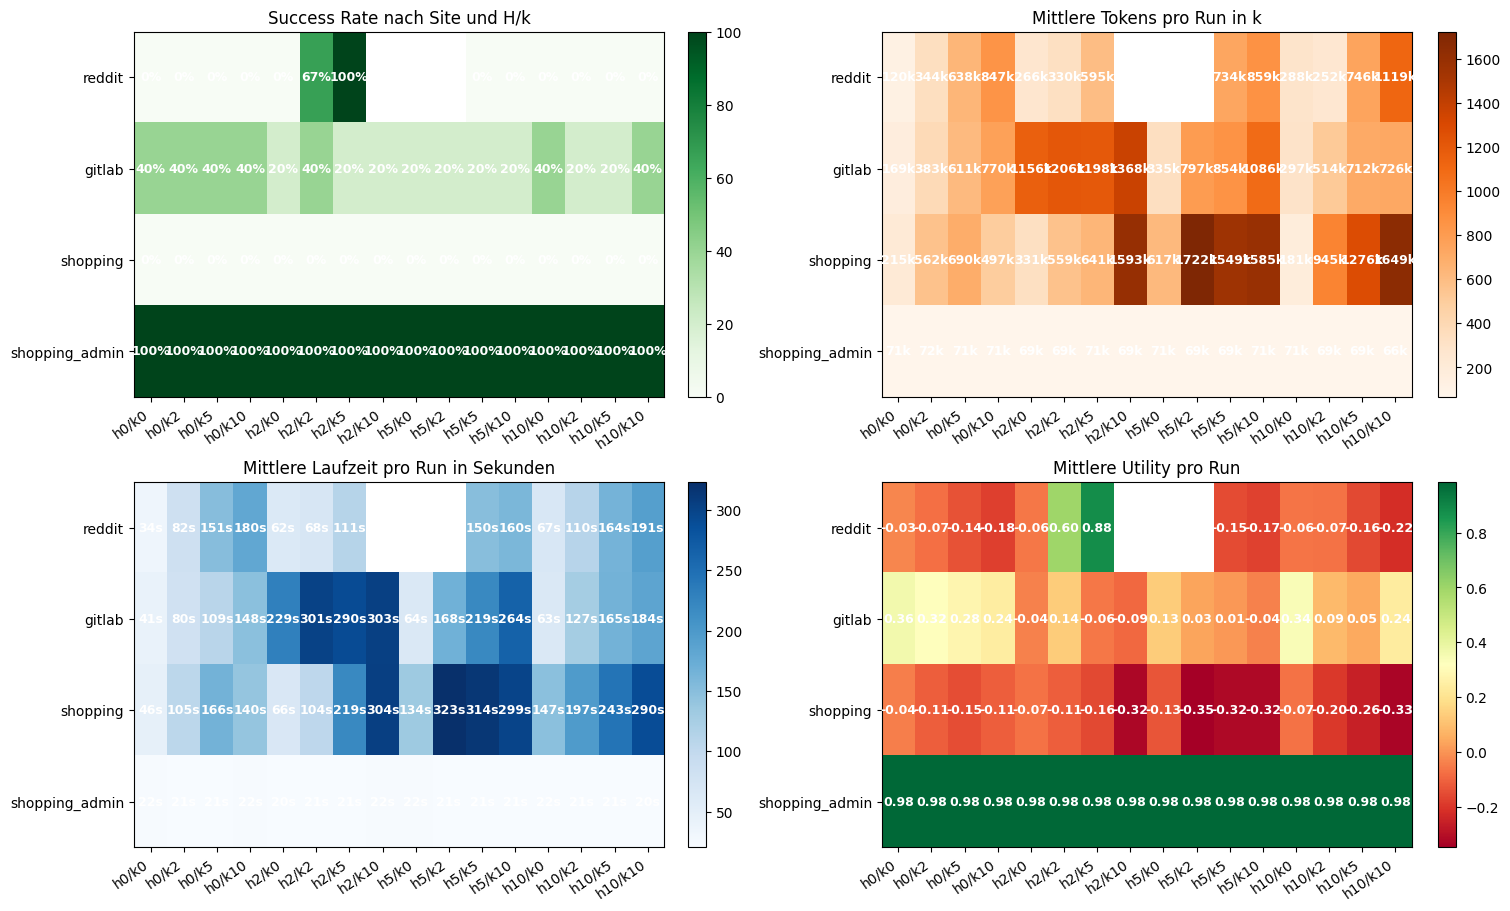

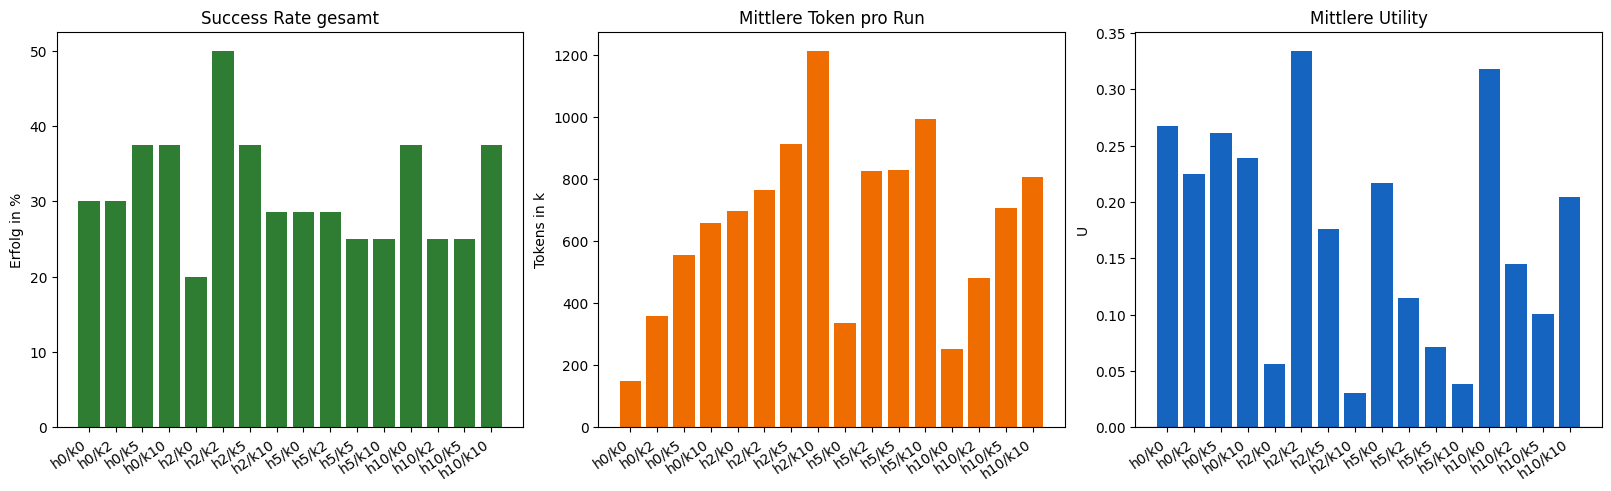

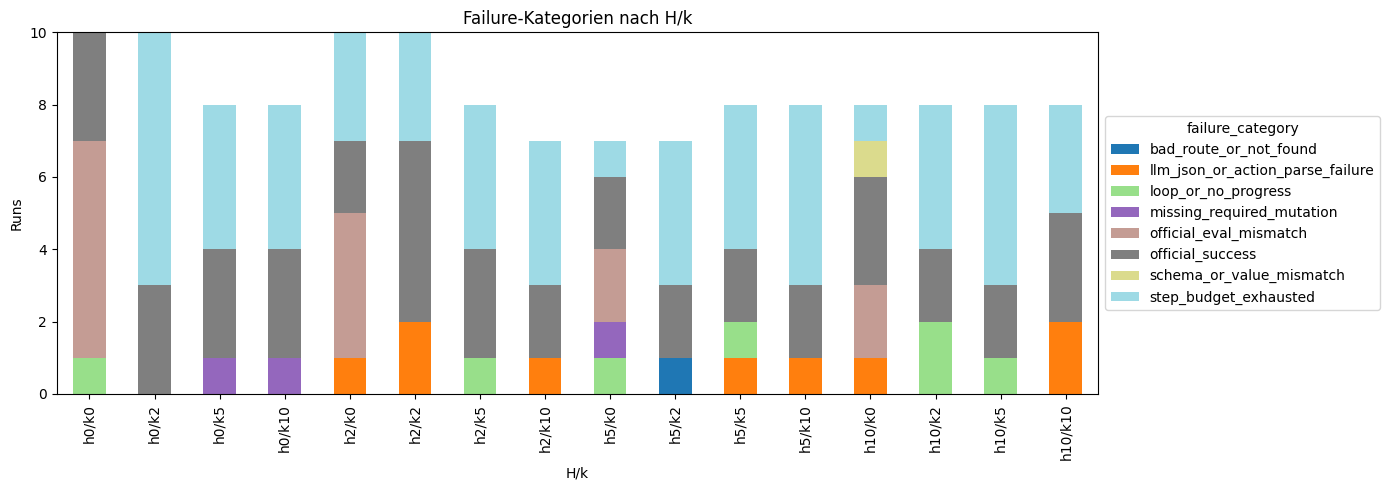

**h2/k2 Detailanalyse:** 5 Fehlschlaege von 10 Runs.

,task_id,site,task_type,task_capability,failure_category,total_steps,total_tokens,runtime_s,runtime_invalid_actions,runtime_loop_events,num_step_errors,last_step_error,output_dir
37,444,gitlab,MUTATE,mutate_gitlab_file_edit,step_budget_exhausted,30,2655339,454.552,1,12,0,NaN,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
53,522,gitlab,MUTATE,mutate_gitlab_fork,llm_json_or_action_parse_failure,26,1136686,411.161,16,14,15,Action target '509' is not a current interacti...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
69,800,gitlab,MUTATE,mutate_gitlab_group,llm_json_or_action_parse_failure,30,1812883,486.093,9,15,7,Action target '456' is not a current interacti...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
93,644,reddit,MUTATE,mutate_forum_post,step_budget_exhausted,8,340044,68.921,0,2,0,NaN,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
97,387,shopping,NAVIGATE,retrieve_reviews,step_budget_exhausted,10,559486,103.888,0,1,0,NaN,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...


,failure_category,h2k2_count
0,step_budget_exhausted,3
1,llm_json_or_action_parse_failure,2


**Automatische Hinweise fuer bessere h2/k2-Laeufe**

- Executor-Prompt/Candidate-Auswahl weiter schaerfen: mehrere h2/k2-Fehler entstehen, weil das Modell sichtbare Labels, Selektoren oder nicht aktuelle `bid`s nutzt.
- Fuer Shopping-/MUTATE-Runs koennte `--max-steps` testweise von 15 auf 20 oder 25 steigen; h2/k2 plant besser, braucht aber oft mehr Schritte.
- Grounding erweitern: mehr Kandidaten oder fokussierte Kandidaten fuer Formulare, Grid-Zeilen und Produktbuttons in den Prompt aufnehmen.

In [130]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

summary_csv = ROOT / 'runs/hk-agent' / EXPERIMENT_NAME / 'summary.csv'
if not summary_csv.exists():
    print('Summary not found yet:', summary_csv)
else:
    eval_df = pd.read_csv(summary_csv).copy()

    def as_bool(series):
        return series.fillna(False).astype(str).str.lower().isin({'true', '1', 'yes', 'success'})

    if 'official_success' not in eval_df.columns:
        raise KeyError('official_success fehlt in summary.csv')

    eval_df['official_success_bool'] = as_bool(eval_df['official_success'])
    if 'contamination_adjusted_success' in eval_df.columns:
        eval_df['contamination_adjusted_success_bool'] = eval_df['official_success_bool'] | as_bool(eval_df['contamination_adjusted_success'])
    else:
        eval_df['contamination_adjusted_success_bool'] = eval_df['official_success_bool']
    if 'evaluation_success' in eval_df.columns:
        eval_df['success_bool'] = as_bool(eval_df['evaluation_success'])
        success_label = str(eval_df.get('evaluation_success_policy', pd.Series([SUCCESS_POLICY])).dropna().iloc[-1])
    else:
        eval_df['success_bool'] = eval_df['contamination_adjusted_success_bool'] if USE_CONTAMINATION_ADJUSTED_SUCCESS else eval_df['official_success_bool']
        success_label = 'contamination_adjusted' if USE_CONTAMINATION_ADJUSTED_SUCCESS else 'webarena'
    eval_df['success'] = eval_df['success_bool'].astype(float)
    eval_df['site_category'] = eval_df.get('site', 'unknown').fillna('unknown').astype(str)
    eval_df['hk'] = 'h' + eval_df['h'].astype(str) + '/k' + eval_df['k'].astype(str)
    eval_df['runtime_s'] = eval_df.get('total_runtime_ms', pd.Series(0, index=eval_df.index)).fillna(0) / 1000.0
    eval_df['tokens'] = eval_df.get('total_tokens', pd.Series(0, index=eval_df.index)).fillna(0).astype(float)
    eval_df['tokens_k'] = eval_df['tokens'] / 1_000.0
    eval_df['tokens_m'] = eval_df['tokens'] / 1_000_000.0

    # Gemma MaaS Kostenparameter laut aktueller Experimentannahme.
    # Input/Prompt: 0.15 USD pro 1M Tokens, Output/Completion: 0.60 USD pro 1M Tokens, Cache-Hit: 0.015 USD pro 1M Tokens.
    INPUT_PRICE_PER_1M_USD = 0.15
    OUTPUT_PRICE_PER_1M_USD = 0.60
    CACHE_HIT_PRICE_PER_1M_USD = 0.015
    CACHE_HIT_RATE = 0.0  # Sensitivitaetsparameter: 0.0 = konservativ ohne Cache-Gutschrift.

    # Neue Runs schreiben prompt_tokens/completion_tokens direkt. Alte CSVs fallen transparent auf total_tokens als Input-Approximation zurueck.
    if {'prompt_tokens', 'completion_tokens'}.issubset(eval_df.columns):
        eval_df['input_tokens_est'] = eval_df['prompt_tokens'].fillna(0).astype(float)
        eval_df['output_tokens_est'] = eval_df['completion_tokens'].fillna(0).astype(float)
        missing_split = eval_df['input_tokens_est'].eq(0) & eval_df['output_tokens_est'].eq(0) & eval_df['tokens'].gt(0)
        eval_df.loc[missing_split, 'input_tokens_est'] = eval_df.loc[missing_split, 'tokens']
    else:
        eval_df['input_tokens_est'] = eval_df['tokens']
        eval_df['output_tokens_est'] = 0.0

    eval_df['cache_hit_tokens_est'] = eval_df['input_tokens_est'] * CACHE_HIT_RATE
    eval_df['billable_input_tokens_est'] = eval_df['input_tokens_est'] - eval_df['cache_hit_tokens_est']
    eval_df['estimated_token_cost_usd'] = (
        eval_df['billable_input_tokens_est'] / 1_000_000 * INPUT_PRICE_PER_1M_USD
        + eval_df['output_tokens_est'] / 1_000_000 * OUTPUT_PRICE_PER_1M_USD
        + eval_df['cache_hit_tokens_est'] / 1_000_000 * CACHE_HIT_PRICE_PER_1M_USD
    )

    # Masterarbeits-Utility: Success bleibt dominant, Kosten/Zeit werden als transparente Penalty abgezogen.
    # Bei USE_CONTAMINATION_ADJUSTED_SUCCESS=True nutzt Success die transparente Zusatzmetrik, official_success bleibt unveraendert.
    # Lambda_tok wird hier aus realen USD-Kosten abgeleitet; lambda_time bleibt ein expliziter Sensitivitaetsparameter.
    LAMBDA_COST = 1.0
    LAMBDA_TIME = 1 / 3600
    eval_df['utility'] = eval_df['success'] - (LAMBDA_COST * eval_df['estimated_token_cost_usd']) - (LAMBDA_TIME * eval_df['runtime_s'])

    key_cols = ['task_id', 'h', 'k']
    eval_df = eval_df.drop_duplicates(key_cols, keep='last')
    planned_keys = None
    if all(name in globals() for name in ['TASK_IDS', 'HS', 'KS']):
        planned_task_ids = [int(x) for x in TASK_IDS]
        planned_hs = [int(x) for x in HS]
        planned_ks = [int(x) for x in KS]
        planned_keys = pd.MultiIndex.from_product(
            [planned_task_ids, planned_hs, planned_ks],
            names=key_cols,
        ).to_frame(index=False)

        observed_keys = eval_df[key_cols].drop_duplicates().assign(observed=True)
        coverage_detail = planned_keys.merge(observed_keys, on=key_cols, how='left')
        coverage_detail['observed'] = coverage_detail['observed'].fillna(False).astype(bool)
        coverage_by_hk = (
            coverage_detail.groupby(['h', 'k'])
            .agg(expected_runs=('task_id', 'count'), observed_runs=('observed', 'sum'))
            .reset_index()
        )
        coverage_by_hk['missing_runs'] = coverage_by_hk['expected_runs'] - coverage_by_hk['observed_runs']
        coverage_by_hk['complete'] = coverage_by_hk['missing_runs'].eq(0)
        display(Markdown('**Coverage-Hinweis:** Die folgende Kosten-/Utility-Auswertung wird auf die aktuelle `TASK_IDS x HS x KS`-Matrix gefiltert. Unvollstaendige H/k-Zellen sind sichtbar und sollten nicht als finaler Vergleich interpretiert werden.'))
        display(coverage_by_hk.sort_values(['h', 'k']))
        eval_df = eval_df.merge(planned_keys, on=key_cols, how='inner')
        hk_order = [f'h{h}/k{k}' for h in planned_hs for k in planned_ks]
    else:
        def hk_sort_key(value):
            try:
                h_part, k_part = str(value).replace('h', '', 1).split('/k', 1)
                return int(h_part), int(k_part)
            except Exception:
                return 999, 999

        hk_order = sorted(eval_df['hk'].dropna().unique(), key=hk_sort_key)

    site_order = ['reddit', 'gitlab', 'shopping', 'shopping_admin']

    def ordered_site_index(frame):
        remaining = [site for site in frame.index if site not in site_order]
        return [site for site in site_order if site in frame.index] + sorted(remaining)

    agg = (
        eval_df.groupby(['site_category', 'h', 'k', 'hk'], dropna=False)
        .agg(
            runs=('task_id', 'count'),
            tasks=('task_id', 'nunique'),
            official_successes=('official_success_bool', 'sum'),
            successes=('success', 'sum'),
            success_rate=('success', 'mean'),
            mean_score=('official_score', 'mean'),
            total_tokens=('tokens', 'sum'),
            mean_tokens=('tokens', 'mean'),
            mean_tokens_k=('tokens_k', 'mean'),
            mean_input_tokens_k=('input_tokens_est', lambda x: x.mean() / 1000),
            mean_output_tokens_k=('output_tokens_est', lambda x: x.mean() / 1000),
            mean_estimated_token_cost_usd=('estimated_token_cost_usd', 'mean'),
            total_estimated_token_cost_usd=('estimated_token_cost_usd', 'sum'),
            total_runtime_s=('runtime_s', 'sum'),
            mean_runtime_s=('runtime_s', 'mean'),
            mean_steps=('total_steps', 'mean'),
            invalid_actions=('runtime_invalid_actions', 'sum'),
            loop_events=('runtime_loop_events', 'sum'),
            mean_utility=('utility', 'mean'),
            total_utility=('utility', 'sum'),
        )
        .reset_index()
        .sort_values(['site_category', 'h', 'k'])
    )

    display(Markdown(
        f"**Kostenparameter:** Input `${INPUT_PRICE_PER_1M_USD:.3f}`/1M, Output `${OUTPUT_PRICE_PER_1M_USD:.3f}`/1M, Cache-Hit `${CACHE_HIT_PRICE_PER_1M_USD:.3f}`/1M, Cache-Hit-Rate `{CACHE_HIT_RATE:.0%}`. "
        f"**Utility:** `U = Success - {LAMBDA_COST:g} * estimated_token_cost_usd - {LAMBDA_TIME:g} * runtime_s`. Success-Metrik: `{success_label}`."
    ))

    display_cols = [
        'site_category', 'h', 'k', 'runs', 'tasks', 'official_successes', 'successes', 'success_rate',
        'mean_score', 'mean_tokens_k', 'mean_input_tokens_k', 'mean_output_tokens_k',
        'mean_estimated_token_cost_usd', 'mean_runtime_s', 'mean_steps',
        'invalid_actions', 'loop_events', 'mean_utility', 'total_utility',
    ]
    display(
        agg[display_cols]
        .style.format({
            'official_successes': '{:.0f}',
            'successes': '{:.0f}',
            'success_rate': '{:.1%}',
            'mean_score': '{:.2f}',
            'mean_tokens_k': '{:.1f}',
            'mean_runtime_s': '{:.1f}',
            'mean_steps': '{:.1f}',
            'mean_input_tokens_k': '{:.1f}',
            'mean_output_tokens_k': '{:.1f}',
            'mean_estimated_token_cost_usd': '${:.4f}',
            'total_estimated_token_cost_usd': '${:.4f}',
            'invalid_actions': '{:.0f}',
            'loop_events': '{:.0f}',
            'mean_utility': '{:.3f}',
            'total_utility': '{:.3f}',
        })
        .background_gradient(subset=['success_rate', 'mean_utility'], cmap='Greens')
        .background_gradient(subset=['mean_tokens_k', 'mean_estimated_token_cost_usd', 'mean_runtime_s'], cmap='Oranges')
    )

    by_hk = (
        eval_df.groupby(['h', 'k', 'hk'])
        .agg(
            runs=('task_id', 'count'),
            successes=('success', 'sum'),
            success_rate=('success', 'mean'),
            mean_tokens_k=('tokens_k', 'mean'),
            mean_estimated_token_cost_usd=('estimated_token_cost_usd', 'mean'),
            mean_runtime_s=('runtime_s', 'mean'),
            mean_utility=('utility', 'mean'),
        )
        .reset_index()
        .sort_values(['h', 'k'])
    )
    display(Markdown('**Gesamtvergleich nach H/k**'))
    display(by_hk.style.format({
        'successes': '{:.0f}',
        'success_rate': '{:.1%}',
        'mean_tokens_k': '{:.1f}',
        'mean_runtime_s': '{:.1f}',
        'mean_estimated_token_cost_usd': '${:.4f}',
        'mean_utility': '{:.3f}',
    }))

    best_by_site = (
        agg.sort_values(['site_category', 'mean_utility'], ascending=[True, False])
        .groupby('site_category', as_index=False)
        .head(1)
        [['site_category', 'hk', 'runs', 'successes', 'success_rate', 'mean_tokens_k', 'mean_estimated_token_cost_usd', 'mean_runtime_s', 'mean_utility']]
    )
    display(Markdown('**Beste H/k-Kombination pro Site nach mittlerem Utility**'))
    display(best_by_site.style.format({
        'successes': '{:.0f}',
        'success_rate': '{:.1%}',
        'mean_tokens_k': '{:.1f}',
        'mean_runtime_s': '{:.1f}',
        'mean_estimated_token_cost_usd': '${:.4f}',
        'mean_utility': '{:.3f}',
    }))

    display(Markdown('**Geschaetzte Tokenkosten nach Site und H/k**'))
    cost_table = agg.pivot_table(index='site_category', columns='hk', values='mean_estimated_token_cost_usd', aggfunc='mean')
    cost_table = cost_table.reindex(index=ordered_site_index(cost_table), columns=[c for c in hk_order if c in cost_table.columns])
    display(cost_table.style.format('${:.4f}').background_gradient(cmap='Oranges'))

    def pivot(metric):
        table = agg.pivot_table(index='site_category', columns='hk', values=metric, aggfunc='mean')
        table = table.reindex(index=ordered_site_index(table), columns=[c for c in hk_order if c in table.columns])
        return table

    def plot_heatmap(ax, data, title, fmt='{:.2f}', cmap='viridis', suffix=''):
        values = data.to_numpy(dtype=float)
        masked = np.ma.masked_invalid(values)
        im = ax.imshow(masked, cmap=cmap, aspect='auto')
        ax.set_title(title)
        ax.set_xticks(range(len(data.columns)))
        ax.set_xticklabels(data.columns, rotation=35, ha='right')
        ax.set_yticks(range(len(data.index)))
        ax.set_yticklabels(data.index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if not np.isfinite(values[i, j]):
                    continue
                ax.text(j, i, fmt.format(values[i, j]) + suffix, ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
    plot_heatmap(axes[0, 0], pivot('success_rate') * 100, 'Success Rate nach Site und H/k', fmt='{:.0f}', cmap='Greens', suffix='%')
    plot_heatmap(axes[0, 1], pivot('mean_tokens_k'), 'Mittlere Tokens pro Run in k', fmt='{:.0f}', cmap='Oranges', suffix='k')
    plot_heatmap(axes[1, 0], pivot('mean_runtime_s'), 'Mittlere Laufzeit pro Run in Sekunden', fmt='{:.0f}', cmap='Blues', suffix='s')
    plot_heatmap(axes[1, 1], pivot('mean_utility'), 'Mittlere Utility pro Run', fmt='{:.2f}', cmap='RdYlGn')
    plt.show()

    # Erfolgs-/Kostenprofil pro H/k als Balkenplot.
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    x = np.arange(len(by_hk))
    axes[0].bar(x, by_hk['success_rate'] * 100, color='#2e7d32')
    axes[0].set_title('Success Rate gesamt')
    axes[0].set_ylabel('Erfolg in %')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(by_hk['hk'], rotation=35, ha='right')

    axes[1].bar(x, by_hk['mean_tokens_k'], color='#ef6c00')
    axes[1].set_title('Mittlere Token pro Run')
    axes[1].set_ylabel('Tokens in k')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(by_hk['hk'], rotation=35, ha='right')

    axes[2].bar(x, by_hk['mean_utility'], color='#1565c0')
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_title('Mittlere Utility')
    axes[2].set_ylabel('U')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(by_hk['hk'], rotation=35, ha='right')
    plt.show()

    if 'failure_category' in eval_df.columns:
        fail_counts = (
            eval_df.assign(failure_category=eval_df['failure_category'].fillna('unknown'))
            .groupby(['hk', 'failure_category'])
            .size()
            .unstack(fill_value=0)
            .reindex([c for c in hk_order if c in eval_df['hk'].unique()])
        )
        ax = fail_counts.plot(kind='bar', stacked=True, figsize=(14, 5), colormap='tab20')
        ax.set_title('Failure-Kategorien nach H/k')
        ax.set_xlabel('H/k')
        ax.set_ylabel('Runs')
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='failure_category')
        plt.tight_layout()
        plt.show()

    # Detailblick: Was verhindert h2/k2 noch?
    h2k2_failures = eval_df[(eval_df['h'].eq(2)) & (eval_df['k'].eq(2)) & (eval_df['success'].eq(0))].copy()
    display(Markdown(f'**h2/k2 Detailanalyse:** {len(h2k2_failures)} Fehlschlaege von {len(eval_df[(eval_df["h"].eq(2)) & (eval_df["k"].eq(2))])} Runs.'))
    if not h2k2_failures.empty:
        detail_cols = [
            'task_id', 'site', 'task_type', 'task_capability', 'failure_category',
            'total_steps', 'total_tokens', 'runtime_s', 'runtime_invalid_actions',
            'runtime_loop_events', 'num_step_errors', 'last_step_error', 'output_dir'
        ]
        display(h2k2_failures[[c for c in detail_cols if c in h2k2_failures.columns]])
        display(h2k2_failures['failure_category'].fillna('unknown').value_counts().rename_axis('failure_category').reset_index(name='h2k2_count'))

        recommendations = []
        if h2k2_failures['failure_category'].astype(str).str.contains('llm_json_or_action_parse_failure', na=False).any():
            recommendations.append('- Executor-Prompt/Candidate-Auswahl weiter schaerfen: mehrere h2/k2-Fehler entstehen, weil das Modell sichtbare Labels, Selektoren oder nicht aktuelle `bid`s nutzt.')
        if h2k2_failures['failure_category'].astype(str).str.contains('step_budget_exhausted', na=False).any():
            recommendations.append('- Fuer Shopping-/MUTATE-Runs koennte `--max-steps` testweise von 15 auf 20 oder 25 steigen; h2/k2 plant besser, braucht aber oft mehr Schritte.')
        if h2k2_failures['failure_category'].astype(str).str.contains('missing_required_mutation', na=False).any():
            recommendations.append('- MUTATE-Finalisierung weiter verbessern: vor `SUCCESS` sollte ein sichtbarer Zustand nach der letzten Mutation nochmals aktiv validiert werden.')
        if h2k2_failures['failure_category'].astype(str).str.contains('loop_or_no_progress', na=False).any():
            recommendations.append('- Runtime-Replanning staerker machen: bei wiederholtem gleichen URL-/Action-Muster frueher neuen Subgoal verlangen statt weiter im Loop zu bleiben.')
        if h2k2_failures.get('runtime_invalid_actions', pd.Series(0, index=h2k2_failures.index)).fillna(0).sum() > 0:
            recommendations.append('- Grounding erweitern: mehr Kandidaten oder fokussierte Kandidaten fuer Formulare, Grid-Zeilen und Produktbuttons in den Prompt aufnehmen.')
        display(Markdown('**Automatische Hinweise fuer bessere h2/k2-Laeufe**\n\n' + '\n'.join(recommendations)))


## 8. Stop Proxy

Nur relevant, wenn `USE_VERTEX_PROXY=True` und der Proxy in diesem Kernel gestartet wurde.


In [153]:
if proxy_proc is None:
    if globals().get('proxy_reused_existing'):
        print('Existing proxy was reused; leaving it running.')
    else:
        print('No proxy process to stop.')
else:
    proxy_proc.terminate()
    try:
        proxy_proc.wait(timeout=10)
    except subprocess.TimeoutExpired:
        proxy_proc.kill()
    print('proxy_stopped')


proxy_stopped
